In [80]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import joblib 


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [81]:
run="1"

In [82]:
bdt_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/BDT_results_limited_sideband_b.pk")
ANN_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/ANN_results_relu_run"+run+"_limited_sideband_b.pk")

ANN_results['BDT']=bdt_results['Yhat']

ANN_results.head()

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz,PhiKK,type,InvM,Class_pre,Class_adv,BDT
0,0.000000,0.892503,-9999.000000,-9999.000000,-9999.000000,337.520844,46.779259,1450.582764,0.046091,-0.079418,1.403741,0.016821,0.031383,1.080163,0.0,tritrig,1.000543,0.042132,0.218768,0.425883
1,1.085953,1.589177,-233.336044,41.034149,1450.371948,238.812180,-38.934586,1449.834595,0.047471,0.025943,0.973056,0.038393,-0.042895,1.489896,0.0,tritrig,1.009053,0.003272,0.016746,0.304193
2,0.000000,1.724564,-9999.000000,-9999.000000,-9999.000000,220.522964,32.286129,1449.614014,0.018133,-0.042591,1.615303,0.055069,0.039147,1.714468,0.0,tritrig,0.991759,0.010809,0.004882,0.345183
3,0.000000,2.579602,-9999.000000,-9999.000000,-9999.000000,161.201752,-26.159630,1449.062744,0.015233,0.080054,0.895970,0.061546,-0.044107,2.395760,0.0,wab,1.105628,0.004679,0.002757,0.330795
4,0.000000,1.834585,-9999.000000,-9999.000000,-9999.000000,201.209885,-26.209942,1449.394531,0.046797,0.011282,0.461370,0.052132,-0.040402,1.847918,0.0,tritrig,1.171021,0.004026,0.002027,0.305196


# Compare Classifiers on testing data

In [83]:
# Split into tritrig and phiKK dataframes
test_df_tritrig = ANN_results[ANN_results['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = ANN_results[ANN_results['type']=="phiKK"].reset_index(drop=True)
test_df_wab = ANN_results[ANN_results['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])



Test AUROC: 0.9978


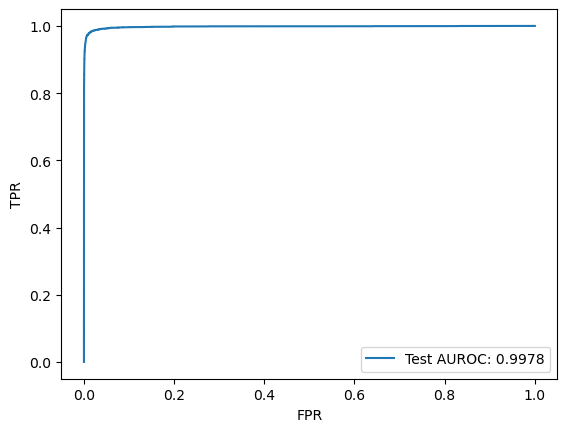

In [84]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.BDT, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

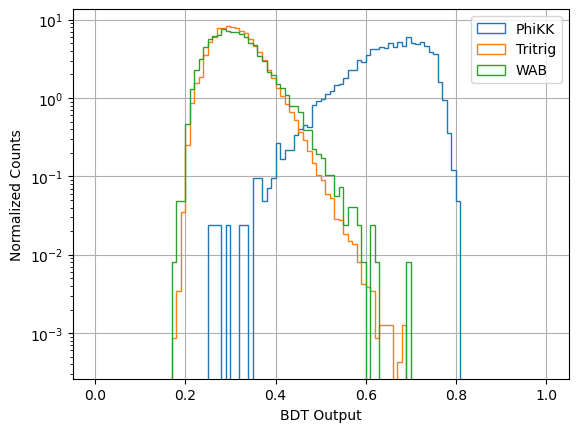

In [85]:
test_df_phiKK.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
#plt.axvline(x=0.4, color='k', linestyle='--', label ="selection line")
plt.xlabel('BDT Output')
plt.ylabel('Normalized Counts')
plt.yscale('log')
plt.legend()

Test AUROC: 0.9960


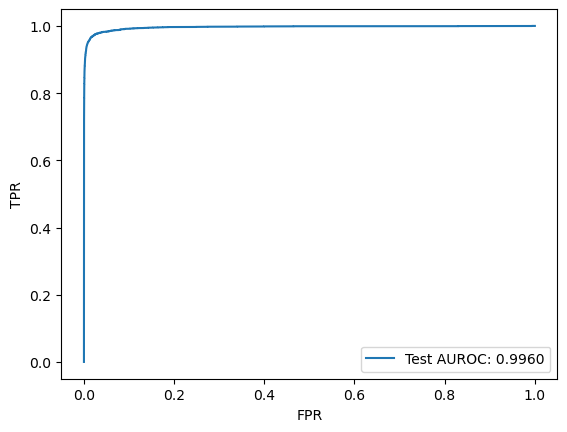

In [86]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_pre, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


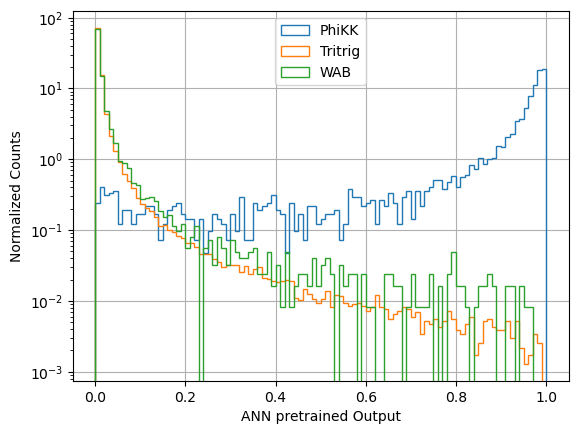

In [87]:
test_df_phiKK.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN pretrained Output')
plt.ylabel('Normalized Counts')
plt.legend()

Test AUROC: 0.9873


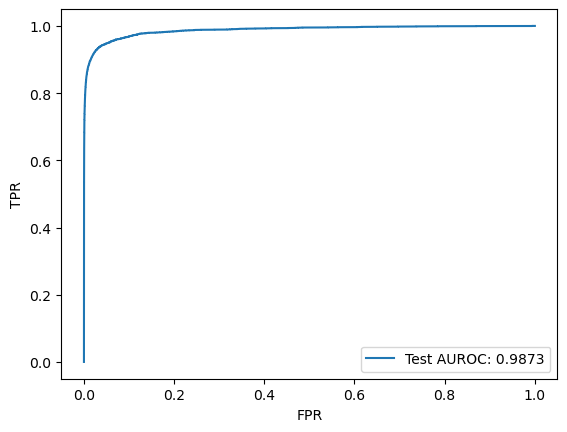

In [88]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_adv, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


In [89]:
a =tpr/fpr

masked = np.ma.masked_invalid(a) # masks inf and nan
if masked.count() == 0: raise ValueError("No finite values")
idx = masked.argmax()

thresholds[idx]

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_49729/3384453741.py:1: RuntimeWarning: divide by zero encountered in divide
  a =tpr/fpr
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_49729/3384453741.py:1: RuntimeWarning: invalid value encountered in divide
  a =tpr/fpr


np.float64(0.9837300582059301)

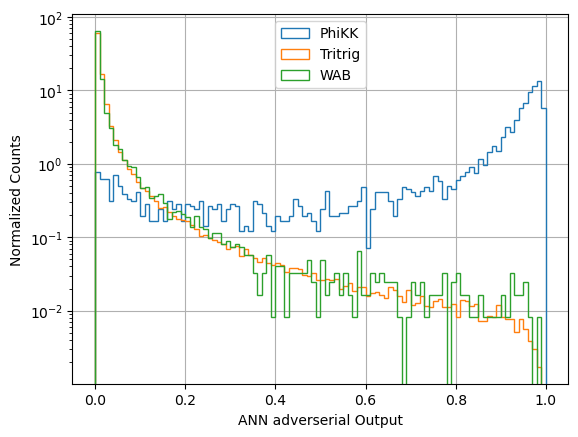

In [90]:
test_df_phiKK.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN adverserial Output')
plt.ylabel('Normalized Counts')
plt.legend()

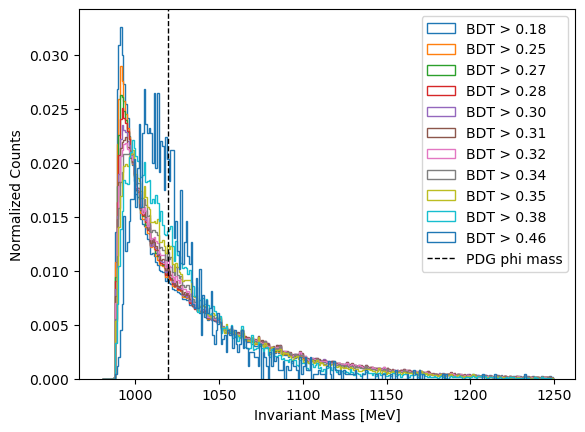

In [91]:
for sel in np.percentile(test_df_bkg['BDT'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['BDT']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'BDT > {sel:.2f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

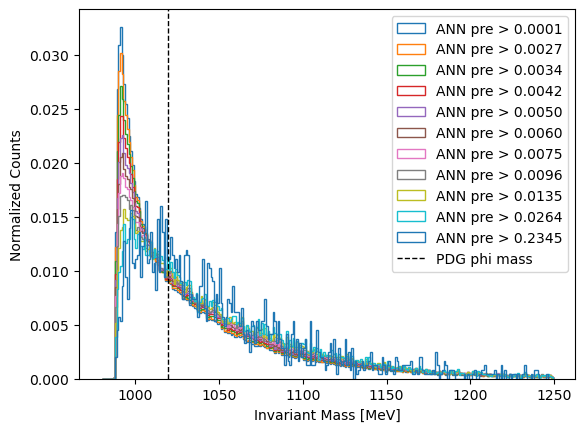

In [92]:
for sel in  np.percentile(test_df_bkg['Class_pre'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_pre']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN pre > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

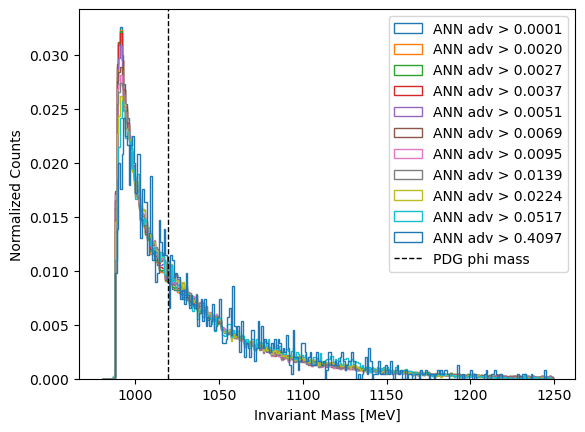

In [93]:
for sel in np.percentile(test_df_bkg['Class_adv'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_adv']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN adv > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

# Compare classifiers on weighted testing data

In [94]:
# Compine dfs according to expected proportions
df_test_combined = pd.concat([test_df_tritrig[0:54013], test_df_wab[0:4897], test_df_phiKK[0:16]], ignore_index=True, sort=False)

print(len(df_test_combined))

58926


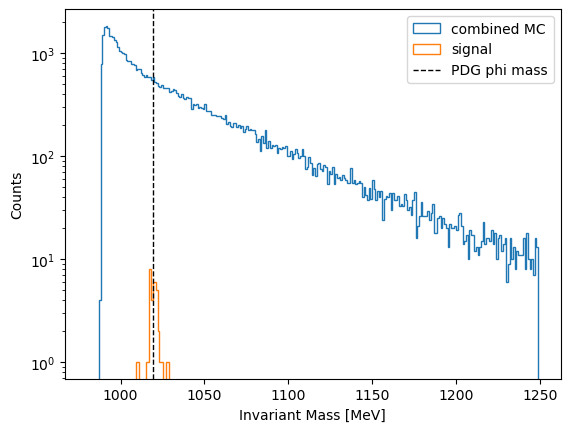

In [95]:
x_vals = 1000*df_test_combined.InvM
x_vals_sig = 1000*test_df_phiKK[0:39].InvM
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label="combined MC")
plt.hist(x_vals_sig, bins=np.arange(980,1250,1), histtype='step',label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

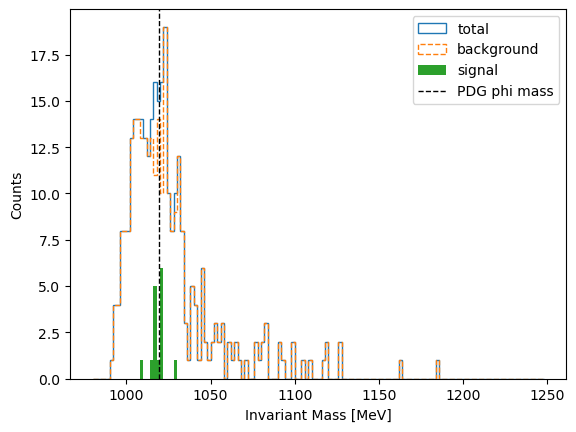

In [96]:
BDT_selection = np.percentile(test_df_bkg['BDT'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['BDT']>BDT_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

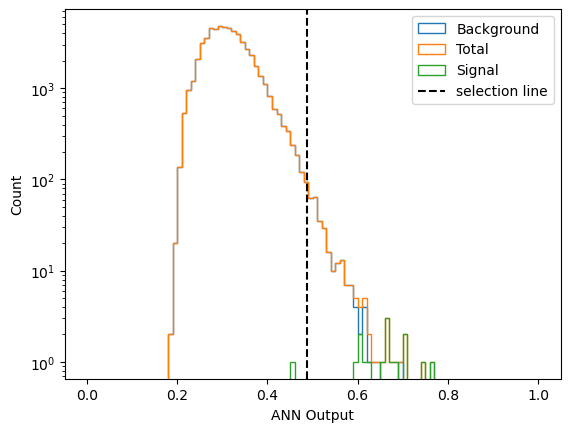

In [97]:
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=BDT_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

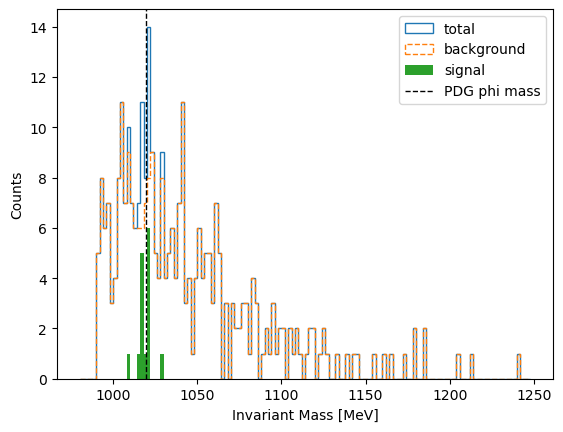

In [98]:
MLP_selection = np.percentile(test_df_bkg['Class_pre'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_pre']>MLP_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

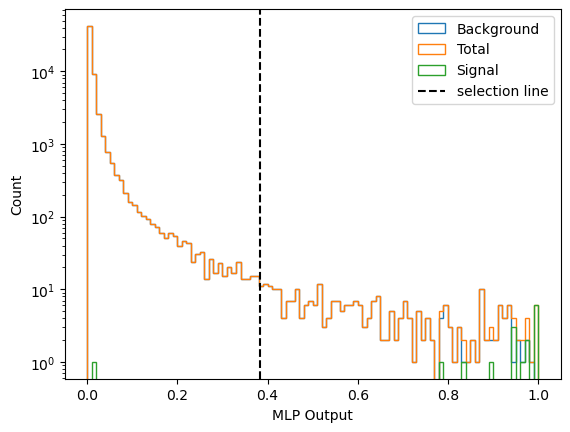

In [99]:
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_pre'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')

plt.axvline(x=MLP_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('MLP Output')
plt.ylabel('Count')

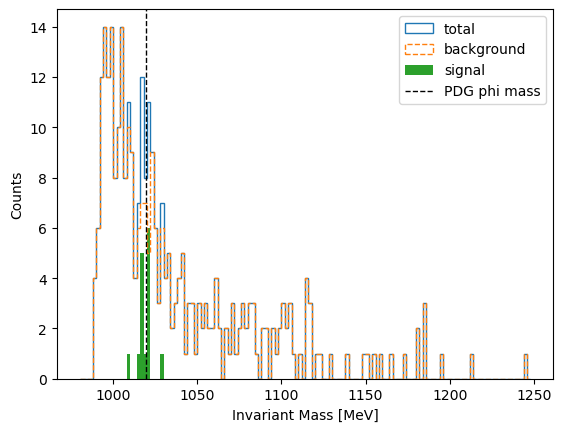

In [100]:
ANN_selection = np.percentile(test_df_bkg['Class_adv'],[99.5])[0]

df_test_combined_cut = df_test_combined[df_test_combined['Class_adv']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

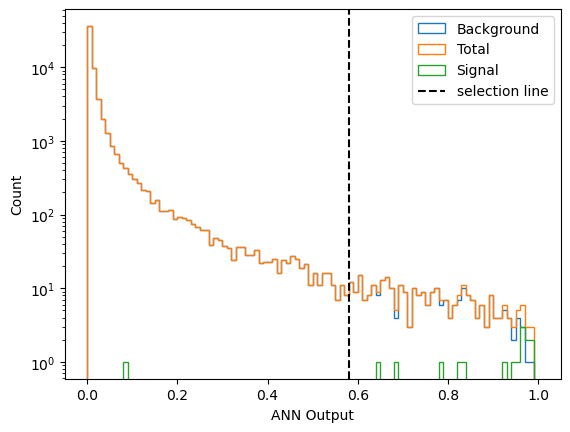

In [101]:
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.axvline(x=ANN_selection, color='k', linestyle='--', label ="selection line")

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

# Apply ANN to data

In [102]:

X_final = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited_sideband_test_b.pk')

print(len(X_final))


58926


In [103]:
final_classifier = mytools.Classifier(in_features=X_final.shape[1]).to(device)
final_classifier.load_state_dict(torch.load("/Users/mghrear/data/ML_data/patch/classifier_adv_relu_run"+str(run)+"_limited_sideband_b.pt", map_location=device))
final_classifier.eval() 

Classifier(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=264, bias=False)
    (1): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=264, out_features=264, bias=False)
    (4): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=264, out_features=128, bias=False)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=False)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=64, bias=False)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [104]:
final_dataset = TensorDataset(torch.from_numpy(X_final.to_numpy().astype(np.float32)) )
final_loader = DataLoader(final_dataset, batch_size=124, shuffle=False)

In [105]:
final_pred = mytools.test_final(final_loader, final_classifier, device)
final_pred=torch.sigmoid(torch.tensor(final_pred)).numpy()



Text(0, 0.5, 'Count')

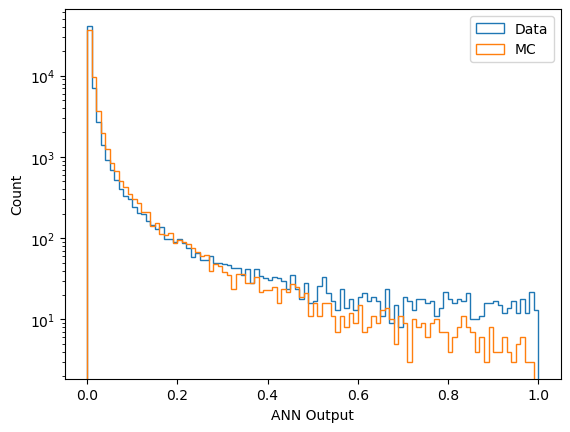

In [106]:
plt.hist(final_pred,bins=np.arange(0,1.01,0.01), histtype='step',label="Data")
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',label='MC')

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

In [107]:
X_final['pred'] = final_pred
X_final['InvM'] = mytools.get_InvM(X_final)

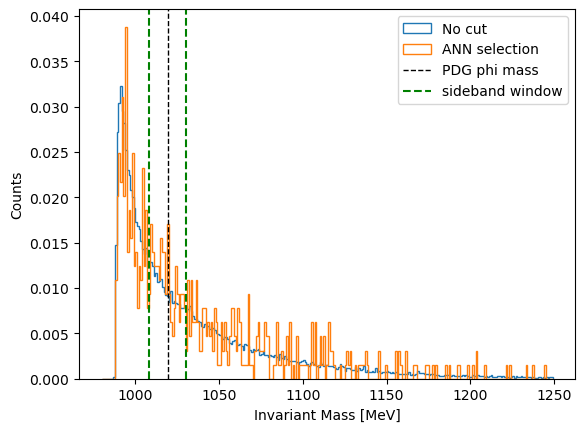

In [108]:
X_final_cut = X_final[X_final['pred']>ANN_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="ANN selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



# Apply BDT to data

In [109]:
bdt_model = joblib.load('/Users/mghrear/data/ML_data/patch/BDT_2019_limited_sideband_b_model.pkl')
X_final = X_final.drop(columns=['pred','InvM'])

In [110]:
Yhat_final = bdt_model.predict_proba(X_final)[:,1]
X_final['pred'] = Yhat_final
X_final['InvM'] = mytools.get_InvM(X_final)


Text(0, 0.5, 'Count')

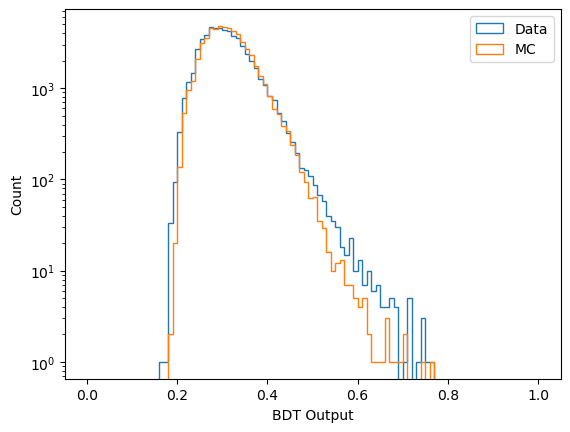

In [111]:
plt.hist(Yhat_final,bins=np.arange(0,1.01,0.01), histtype='step',label="Data")
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',label='MC')

plt.legend()
plt.yscale('log')
plt.xlabel('BDT Output')
plt.ylabel('Count')

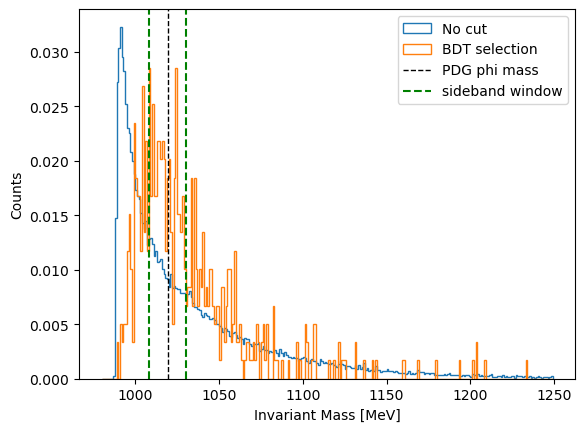

In [112]:
X_final_cut = X_final[X_final['pred']>BDT_selection].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="BDT selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

